# Cannon dynamics

In [7]:
# state: x, y, vx, vy
# control: init vx, vy
import numpy as np
from scipy.integrate import solve_ivp

class CannonSimulator:
    c:float
    g:float = 9.8
    def __init__(self, c):
        self.c = c
    
    def dynamics(self, state, control, dt):
        x, y, vx, vy = state
        
        dx = vx
        dy = vy
        v = np.sqrt(vx**2 + vy**2)
        dvx = -self.c * v * vx
        dvy = -self.c * v * vy - self.g
        return [dx, dy, dvx, dvy]

    def step(self, state, control, dt):
        x, y, vx, vy = state
        return solve_ivp(lambda t, s: self.dynamics(s, control, dt), [0, dt], state).y[:, -1]


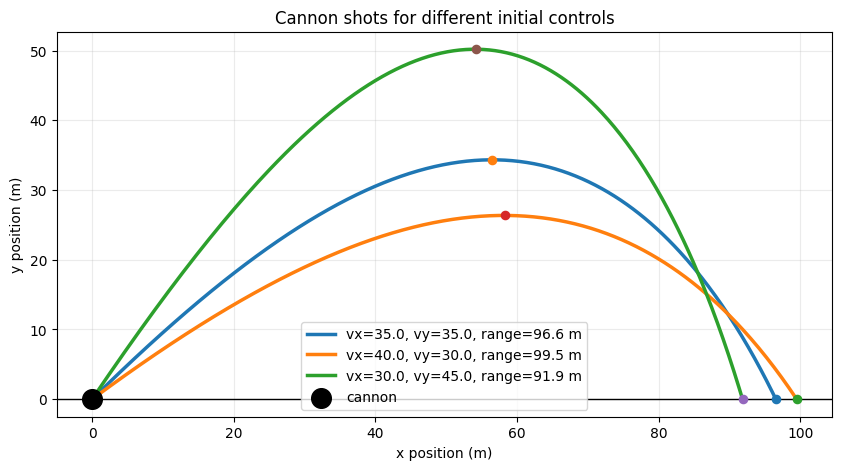

In [8]:
import matplotlib.pyplot as plt

def simulate_shot(control, c=0.01, dt=0.02, max_time=20.0):
    sim = CannonSimulator(c=c)
    control = np.asarray(control, dtype=float)
    state = np.array([0.0, 0.0, control[0], control[1]])
    trajectory = [state.copy()]

    for _ in range(int(max_time / dt)):
        prev_state = state.copy()
        state = sim.step(state, control, dt)

        if state[1] < 0:
            # The last integration step crossed the ground, so interpolate between
            # the previous positive-y state and the current negative-y state.
            alpha = prev_state[1] / (prev_state[1] - state[1])
            landing_state = prev_state + alpha * (state - prev_state)
            trajectory.append(landing_state)
            break

        trajectory.append(state.copy())

    return np.array(trajectory)


def plot_shot(control, c=0.01, dt=0.02, max_time=20.0, ax=None, label=None):
    trajectory = simulate_shot(control, c=c, dt=dt, max_time=max_time)
    x = trajectory[:, 0]
    y = trajectory[:, 1]
    apex_index = np.argmax(y)
    range_x = x[-1]
    max_height = y[apex_index]

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))

    if label is None:
        label = f"vx={control[0]:.1f}, vy={control[1]:.1f}, range={range_x:.1f} m"

    ax.plot(x, y, linewidth=2.5, label=label)
    ax.scatter([range_x], [0], s=35, zorder=5)
    ax.scatter([x[apex_index]], [max_height], s=35, zorder=5)
    return trajectory


controls = [
    np.array([35.0, 35.0]),
    np.array([40.0, 30.0]),
    np.array([30.0, 45.0]),
]

fig, ax = plt.subplots(figsize=(10, 5))
trajectories = [plot_shot(control, ax=ax) for control in controls]

ax.axhline(0, color="black", linewidth=1)
ax.scatter([0], [0], s=200, color="black", zorder=5, label="cannon")
ax.set_title("Cannon shots for different initial controls")
ax.set_xlabel("x position (m)")
ax.set_ylabel("y position (m)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


# Single shot
Only change init state, use simulation to optimize.